## Modelling Strategy

The detection task is formulated as a binary classification problem:

0 → Real financial article  
1 → AI-generated financial article

Models are evaluated progressively:

1. Classical machine learning using TF-IDF
2. Neural network using TF-IDF features
3. Financial-domain transformer model (FinBERT)

This allows comparison between traditional and advanced NLP approaches.

## Import

In [ ]:
import os
os.environ["TORCHVISION_DISABLE_VIDEO"] = "1"

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import torch

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MaxAbsScaler

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [ ]:
# Create folders
import os

project_path = ".."

os.makedirs(
f"{project_path}/results",
    exist_ok=True
)

os.makedirs(
    f"{project_path}/figures",
    exist_ok=True
)

## Load Data

In [ ]:
# Paths
RAW_PATH = "data/raw"
PROCESSED_PATH = "data/processed"

df = pd.read_csv(
    f"{PROCESSED_PATH}/features_dataset.csv"
)

df.head()

,article,label,source_type,prompt_type,positive_score,negative_score,neutral_score,vader_compound,finbert_sentiment,flesch_score,gunning_fog,word_count,sentence_count,avg_sentence_length,capital_ratio,punctuation_count
0,McDonald's is bringing back its Fried Apple Pi...,0,real,original,0.112,0.020,0.868,0.8271,positive,71.695862,9.109360,87.0,9.0,9.666667,0.048780,16.0
1,We recently published Jim Cramer Discussed Exp...,0,real,original,0.037,0.055,0.908,-0.2732,negative,61.532500,11.325926,56.0,4.0,14.000000,0.112045,17.0
2,(Bloomberg) -- For the first time in four year...,0,real,original,0.111,0.095,0.795,0.1280,positive,48.638333,15.666667,81.0,3.0,27.000000,0.106212,10.0
3,Goldman Sachs now sees a smaller chance of a r...,0,real,original,0.202,0.234,0.565,-0.3612,negative,78.087039,9.208772,57.0,6.0,9.500000,0.023333,11.0
4,Stock futures were tumbling on Tuesday as inve...,0,real,original,0.061,0.000,0.939,0.4767,negative,34.868912,17.145578,49.0,6.0,8.166667,0.034783,11.0


In [ ]:
print(df.shape)

print(
    df["label"].value_counts()
)

(400, 16)
label
1    300
0    100
Name: count, dtype: int64


## Baseline Misinformation Detection Models

This section evaluates baseline machine learning models for detecting
AI-generated financial misinformation.

Models:

- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)

Features:

- TF-IDF representations of article text

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## Prepare Data

In [ ]:
X = df["article"]

y = df["label"]

In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

A fixed random state was used to ensure reproducibility.

In [ ]:
# Check Split
print(X_train.shape)
print(X_test.shape)

(320,)
(80,)


## TF-IDF

**TF-IDF Feature Extraction**

TF-IDF was selected as a baseline because it provides an interpretable
representation of important words while remaining computationally efficient.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_test_tfidf = tfidf.transform(
    X_test
)

print(
    X_train_tfidf.shape
)

(320, 4374)


In [ ]:
# Save Vectorizer
joblib.dump(
    tfidf,
    f"{project_path}/results/tfidf_vectorizer.pkl"
)

['/content/drive/MyDrive/TU Dortmund/DAI/dai-mission-group-M/results/tfidf_vectorizer.pkl']

## Helper Function

In [ ]:
def evaluate_model(
    model,
    X_test,
    y_test
):

    predictions = model.predict(
        X_test
    )

    probabilities = model.predict_proba(
        X_test
    )[:,1]

    metrics = {

        "Accuracy":
        accuracy_score(
            y_test,
            predictions
        ),

        "Precision":
        precision_score(
            y_test,
            predictions
        ),

        "Recall":
        recall_score(
            y_test,
            predictions
        ),

        "F1":
        f1_score(
            y_test,
            predictions
        ),

        "ROC_AUC":
        roc_auc_score(
            y_test,
            probabilities
        )
    }

    return (
        metrics,
        predictions,
        probabilities
    )

## Logistic Regression

In [ ]:
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
logistic_metrics, logistic_pred, logistic_prob = evaluate_model(
    logistic,
    X_test_tfidf,
    y_test
)

pd.DataFrame(
    [logistic_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.8,0.789474,1.0,0.882353,0.85


In [ ]:
print(
    classification_report(
        y_test,
        logistic_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.20      0.33        20
           1       0.79      1.00      0.88        60

    accuracy                           0.80        80
   macro avg       0.89      0.60      0.61        80
weighted avg       0.84      0.80      0.75        80



**Logistic Regression Performance**

Recall: 1.00 — The model successfully detected every AI‑generated article in the test set, producing no false negatives.

Precision: 0.789 — The model incorrectly labeled some real, human‑written articles as AI‑generated, resulting in a higher false‑positive rate.

Logistic Regression prioritized capturing all AI‑generated content, achieving perfect recall. The model prioritised sensitivity toward AI-generated content, resulting in higher recall but more false positives.

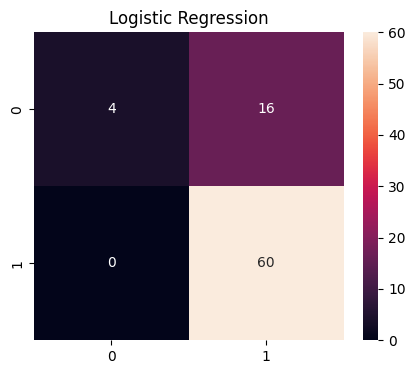

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(
        y_test,
        logistic_pred
    ),
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression"
)

plt.show()

Logistic Regression detected all AI‑generated articles (perfect recall) but misclassified several real ones, showing lower precision.

In [ ]:
# Save Results
pd.DataFrame(
    [logistic_metrics]
).to_csv(
    f"{project_path}/results/logistic_results.csv",
    index=False
)

## Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_tfidf,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
rf_metrics, rf_pred, rf_prob = evaluate_model(
    rf,
    X_test_tfidf,
    y_test
)

pd.DataFrame(
    [rf_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.825,0.96,0.8,0.872727,0.910833


In [ ]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.60      0.90      0.72        20
           1       0.96      0.80      0.87        60

    accuracy                           0.82        80
   macro avg       0.78      0.85      0.80        80
weighted avg       0.87      0.82      0.83        80



**Random Forest Performance**

Precision: 0.96 — The model produced very few false positives; almost every article it labeled as AI‑generated truly was.

Recall: 0.80 — The model missed a portion of AI‑generated articles, indicating under‑detection.

The Random Forest classifier behaved conservatively, prioritizing precision over recall. It reliably avoided mislabeling human‑written articles as AI‑generated but failed to capture all AI‑generated content.

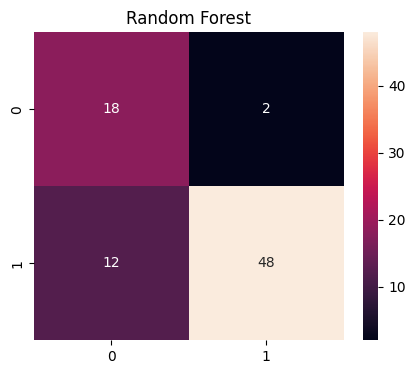

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(
        y_test,
        rf_pred
    ),
    annot=True,
    fmt="d"
)

plt.title(
    "Random Forest"
)

plt.show()

The model correctly classified most samples, showing strong precision but missing a few AI‑generated articles.

In [ ]:
# Feature Importance
importance = pd.DataFrame({
    "feature": tfidf.get_feature_names_out(),
    "importance": rf.feature_importances_
})

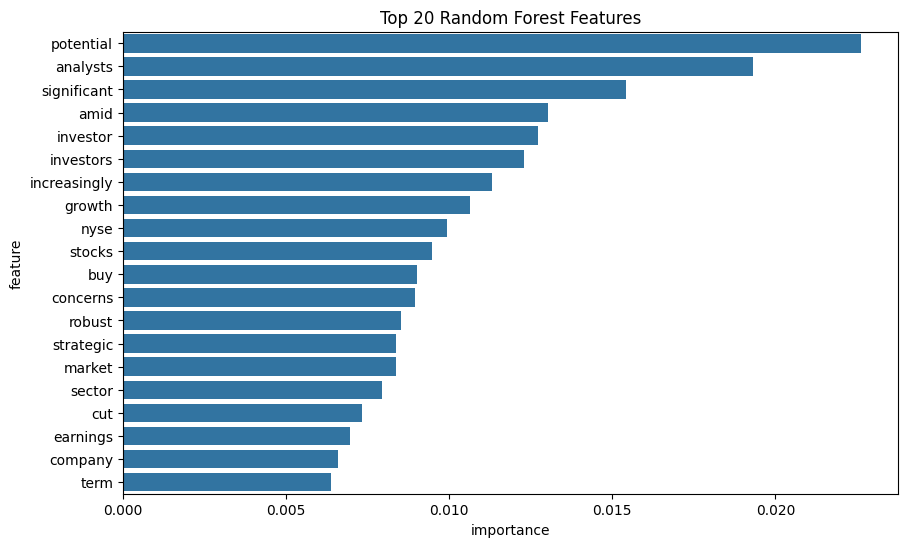

In [ ]:
top20 = importance.sort_values(
    "importance",
    ascending=False
).head(20)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x="importance",
    y="feature"
)

plt.title(
    "Top 20 Random Forest Features"
)

plt.show()

The feature importance analysis shows that certain terms contributed more
strongly to classification decisions. These features represent linguistic
patterns learned from the training data rather than direct indicators of
misinformation.

In [ ]:
# Save Results
pd.DataFrame(
    [rf_metrics]
).to_csv(
    f"{project_path}/results/random_forest_results.csv",
    index=False
)

## SVM

In [ ]:
svm = SVC(
    kernel="linear",
    probability=True,
    random_state=42
)

svm.fit(
    X_train_tfidf,
    y_train
)

SVC(kernel='linear', probability=True, random_state=42)

In [ ]:
svm_metrics, svm_pred, svm_prob = evaluate_model(
    svm,
    X_test_tfidf,
    y_test
)

pd.DataFrame(
    [svm_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.825,0.848485,0.933333,0.888889,0.878333


In [ ]:
print(
    classification_report(
        y_test,
        svm_pred
    )
)

              precision    recall  f1-score   support

           0       0.71      0.50      0.59        20
           1       0.85      0.93      0.89        60

    accuracy                           0.82        80
   macro avg       0.78      0.72      0.74        80
weighted avg       0.81      0.82      0.81        80



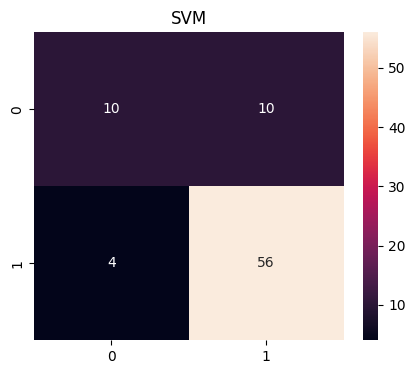

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(
        y_test,
        svm_pred
    ),
    annot=True,
    fmt="d"
)

plt.title(
    "SVM"
)

plt.show()

SVM achieved high recall and balanced performance, correctly identifying most AI‑generated articles with moderate false positives.

In [ ]:
# Save Results
pd.DataFrame(
    [svm_metrics]
).to_csv(
    f"{project_path}/results/svm_results.csv",
    index=False
)

## Model Comparison

In [ ]:
comparison = pd.DataFrame(
    [
        {
            "Model":
            "Logistic Regression",
            **logistic_metrics
        },

        {
            "Model":
            "Random Forest",
            **rf_metrics
        },

        {
            "Model":
            "SVM",
            **svm_metrics
        }
    ]
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.800,0.789474,1.000000,0.882353,0.850000
1,Random Forest,0.825,0.960000,0.800000,0.872727,0.910833
2,SVM,0.825,0.848485,0.933333,0.888889,0.878333


In [ ]:
best_model = comparison.loc[
    comparison["F1"].idxmax()
]

best_model

,2
Model,SVM
Accuracy,0.825
Precision,0.848485
Recall,0.933333
F1,0.888889
ROC_AUC,0.878333


**Best Baseline Model**

Based on F1 score, the Support Vector Machine (SVM) achieved the strongest overall performance, balancing precision and recall while maintaining competitive accuracy.

The model obtained:

- Accuracy: 82.5%
- Precision: 84.8%
- Recall: 93.3%
- F1 Score: 88.9%
- ROC-AUC: 87.8%

These results indicate that AI-generated financial misinformation can be detected using classical machine learning approaches and TF-IDF representations.

## Visualization

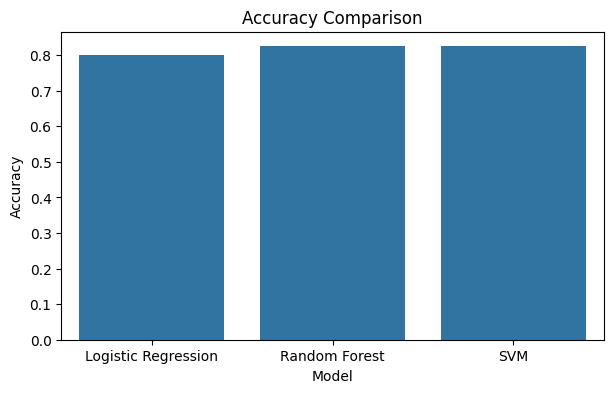

In [ ]:
# Accuracy
plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Accuracy Comparison"
)

plt.show()

Random Forest and SVM slightly outperformed Logistic Regression, both reaching around 83% accuracy.

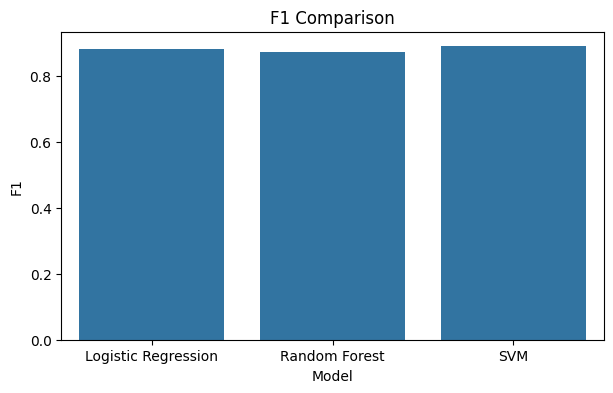

In [ ]:
# F1
plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="F1"
)

plt.title(
    "F1 Comparison"
)

plt.show()

All three baseline models achieved similar F1 scores (~0.87–0.88), reflecting balanced precision and recall.

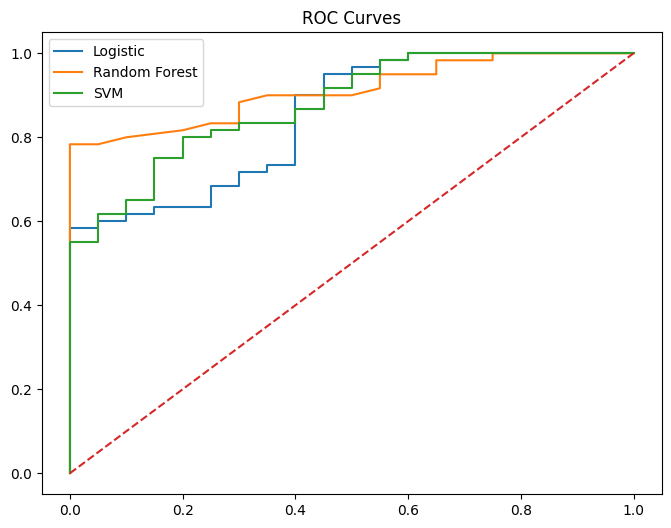

In [ ]:
# ROC Curves
plt.figure(figsize=(8,6))

for name, probs in [
    ("Logistic", logistic_prob),
    ("Random Forest", rf_prob),
    ("SVM", svm_prob)
]:

    fpr, tpr, _ = roc_curve(
        y_test,
        probs
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.legend()

plt.title(
    "ROC Curves"
)

plt.show()

All models performed well; SVM and Random Forest showed slightly stronger ROC curves than Logistic Regression.

In [ ]:
# Save Figures
plt.savefig(
    f"{project_path}/figures/model_accuracy.png",
    bbox_inches="tight"
)

plt.savefig(
    f"{project_path}/figures/f1_comparison.png",
    bbox_inches="tight"
)

plt.savefig(
    f"{project_path}/figures/roc_curves.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

The baseline models show that AI‑generated financial misinformation can be reliably distinguished from real news using TF‑IDF and classical machine learning.

- **SVM** performed best overall, offering strong accuracy and a balanced trade‑off between precision and recall.  
- **Logistic Regression** achieved perfect recall, detecting all AI‑generated articles but producing more false positives.  
- **Random Forest** achieved the highest precision, rarely mislabeling real articles but missing some AI‑generated ones.

These findings support **RQ1**, demonstrating that machine learning methods can effectively detect AI‑generated financial misinformation. The best-performing baseline model (SVM) will serve as a benchmark for comparison with advanced approaches.


## Advanced Detection Models

To evaluate whether advanced NLP-based models can improve the detection of AI-generated financial misinformation, additional models were trained.

The following approaches were evaluated:

- Multi-Layer Perceptron (MLP) Neural Network
- Fine-tuned FinBERT Transformer Model

The neural network uses TF-IDF representations, while FinBERT uses contextual embeddings learned from financial text.

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## Neural Network

In [ ]:
# Scale TF-IDF Features
scaler = MaxAbsScaler()

X_train_scaled = scaler.fit_transform(
    X_train_tfidf
)

X_test_scaled = scaler.transform(
    X_test_tfidf
)

In [ ]:
# Train Neural Network
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate="adaptive",
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(
    X_train_scaled,
    y_train
)

MLPClassifier(early_stopping=True, hidden_layer_sizes=(256, 128),
              learning_rate='adaptive', max_iter=500, random_state=42)

In [ ]:
# Predictions
nn_pred = mlp.predict(
    X_test_scaled
)

nn_prob = mlp.predict_proba(
    X_test_scaled
)[:, 1]

In [ ]:
# Metrics
nn_metrics = {
    "Accuracy":
    accuracy_score(
        y_test,
        nn_pred
    ),

    "Precision":
    precision_score(
        y_test,
        nn_pred
    ),

    "Recall":
    recall_score(
        y_test,
        nn_pred
    ),

    "F1":
    f1_score(
        y_test,
        nn_pred
    ),

    "ROC_AUC":
    roc_auc_score(
        y_test,
        nn_prob
    )
}

pd.DataFrame(
    [nn_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.8,0.814286,0.95,0.876923,0.835833


In [ ]:
# Classification Report
print(
    classification_report(
        y_test,
        nn_pred
    )
)

              precision    recall  f1-score   support

           0       0.70      0.35      0.47        20
           1       0.81      0.95      0.88        60

    accuracy                           0.80        80
   macro avg       0.76      0.65      0.67        80
weighted avg       0.79      0.80      0.77        80



The MLP classifier achieved:

- Accuracy: 0.800
- F1 Score: 0.877
- ROC-AUC: 0.836

The model achieved high recall (0.95), indicating strong detection capability for AI-generated articles.

However, performance remained comparable to traditional TF-IDF-based models, suggesting that a simple neural architecture provides limited improvement without richer text representations.

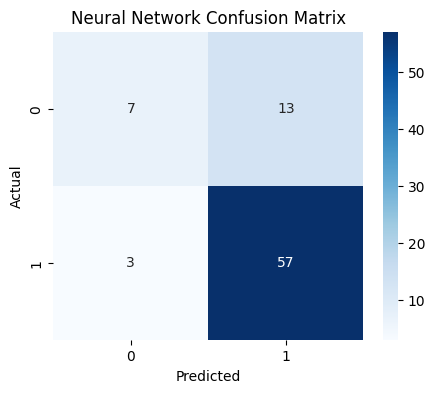

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(
        y_test,
        nn_pred
    ),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Neural Network Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

The neural network captured most AI‑generated articles but misclassified some real ones, showing high recall with moderate precision.

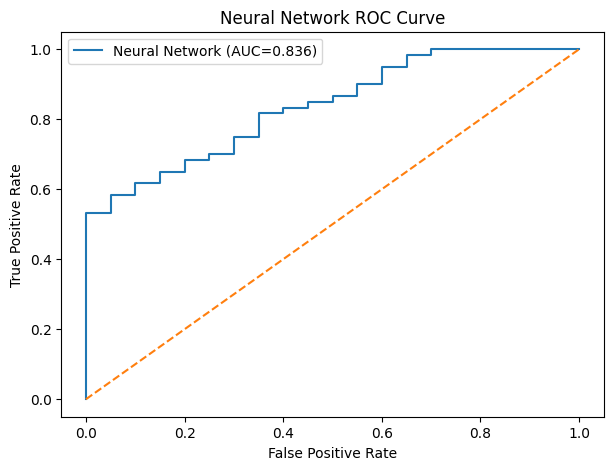

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(
    y_test,
    nn_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Neural Network (AUC={roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Neural Network ROC Curve"
)

plt.legend()

plt.savefig(
    f"{project_path}/figures/neural_network_roc_curve.png",
    bbox_inches="tight"
)

plt.show()

The neural network reached an AUC of 0.836, indicating good discrimination ability but weaker performance than FinBERT.

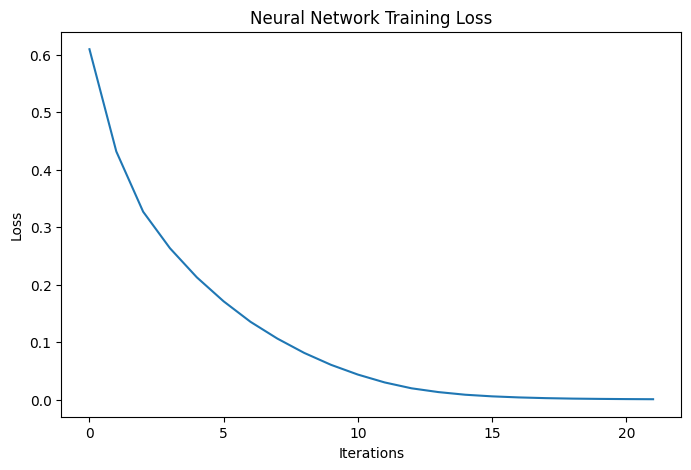

In [ ]:
# Training Curve
plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_)
plt.title("Neural Network Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

Loss steadily decreased across iterations, confirming effective learning and convergence.

In [ ]:
pd.DataFrame(
    [nn_metrics]
).to_csv(
    f"{project_path}/results/neural_network_results.csv",
    index=False
)

## FinBERT Fine-Tuning

FinBERT was selected because financial misinformation detection requires
understanding domain-specific language.

Unlike TF-IDF approaches, FinBERT captures contextual meaning and relationships
between financial terms.

In [ ]:
# Prepare Dataset
finbert_df = df[
    [
        "article",
        "label"
    ]
].copy()

In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    finbert_df["article"],
    finbert_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=finbert_df["label"]
)

In [ ]:
train_dataset = Dataset.from_dict(
    {
        "text": train_texts.tolist(),
        "label": train_labels.tolist()
    }
)

test_dataset = Dataset.from_dict(
    {
        "text": test_texts.tolist(),
        "label": test_labels.tolist()
    }
)

In [ ]:
# Load FinBERT
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
# Tokenize
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

In [ ]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

In [ ]:
train_dataset.set_format(
    "torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

test_dataset.set_format(
    "torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(
        logits,
        axis=1
    )

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1
    )[:,1].numpy()


    return {
        "accuracy":
        accuracy_score(
            labels,
            predictions
        ),

        "precision":
        precision_score(
            labels,
            predictions
        ),

        "recall":
        recall_score(
            labels,
            predictions
        ),

        "f1":
        f1_score(
            labels,
            predictions
        ),

        "roc_auc":
        roc_auc_score(
            labels,
            probabilities
        )
    }

In [ ]:
# Training
os.makedirs(
    f"{project_path}/models",
    exist_ok=True
)

training_args = TrainingArguments(
    output_dir=f"{project_path}/models/finbert_results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.380234,0.351687,0.787500,0.802817,0.950000,0.870229,0.911667
2,0.277817,0.233301,0.900000,0.948276,0.916667,0.932203,0.963333
3,0.096453,0.205904,0.912500,0.949153,0.933333,0.941176,0.970833


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=120, training_loss=0.29475245376427966, metrics={'train_runtime': 131.7477, 'train_samples_per_second': 7.287, 'train_steps_per_second': 0.911, 'total_flos': 252586613145600.0, 'train_loss': 0.29475245376427966, 'epoch': 3.0})

In [ ]:
# Evaluate FinBERT
predictions = trainer.predict(
    test_dataset
)

probs = torch.softmax(
    torch.tensor(
        predictions.predictions
    ),
    dim=1
).numpy()

finbert_pred = np.argmax(
    probs,
    axis=1
)

finbert_prob = probs[:,1]

In [ ]:
finbert_metrics = {
    "Accuracy":
    accuracy_score(
        test_labels,
        finbert_pred
    ),

    "Precision":
    precision_score(
        test_labels,
        finbert_pred
    ),

    "Recall":
    recall_score(
        test_labels,
        finbert_pred
    ),

    "F1":
    f1_score(
        test_labels,
        finbert_pred
    ),

    "ROC_AUC":
    roc_auc_score(
        test_labels,
        finbert_prob
    )
}

pd.DataFrame(
    [finbert_metrics]
)

,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.9125,0.949153,0.933333,0.941176,0.970833


In [ ]:
# Classification report
print(
    classification_report(
        test_labels,
        finbert_pred
    )
)

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        20
           1       0.95      0.93      0.94        60

    accuracy                           0.91        80
   macro avg       0.88      0.89      0.89        80
weighted avg       0.91      0.91      0.91        80



FinBERT achieved the highest performance among evaluated approaches.

Performance:

- Accuracy: 0.913
- Precision: 0.949
- Recall: 0.933
- F1 Score: 0.941
- ROC-AUC: 0.971

The improvement indicates that financial-domain transformer representations capture semantic and linguistic patterns that are not fully represented by TF-IDF features.

*FinBERT was therefore selected as the final detection model.*

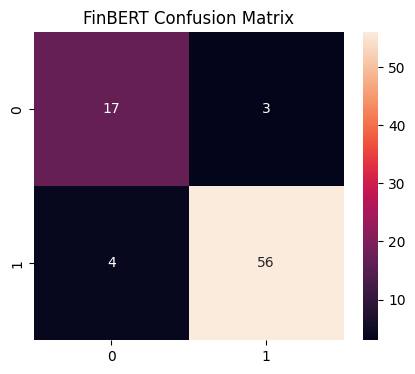

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(
        test_labels,
        finbert_pred
    ),
    annot=True,
    fmt="d"
)

plt.title(
    "FinBERT Confusion Matrix"
)

plt.show()

The model correctly classified most samples, with only a few false positives and false negatives, indicating strong overall accuracy.

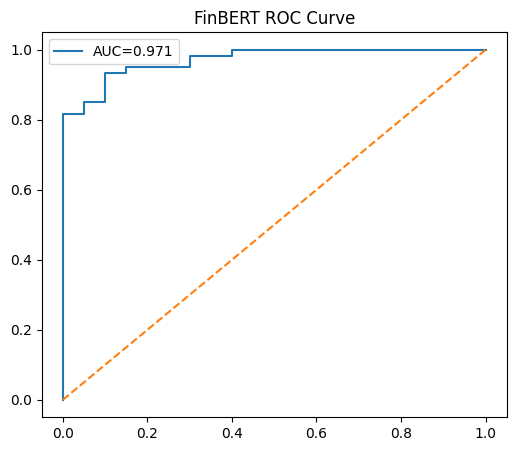

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(
    test_labels,
    finbert_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={finbert_metrics['ROC_AUC']:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.legend()

plt.title("FinBERT ROC Curve")

plt.savefig(
    f"{project_path}/figures/finbert_roc_curve.png",
    bbox_inches="tight"
)

plt.show()

FinBERT achieved an AUC of 0.971, showing excellent discrimination between AI‑generated and real articles.

In [ ]:
pd.DataFrame(
    [finbert_metrics]
).to_csv(
    f"{project_path}/results/finbert_results.csv",
    index=False
)

## Final Comparison Table

The final comparison evaluates traditional machine learning, neural networks, and transformer-based approaches for detecting AI-generated financial misinformation.

In [ ]:
final_comparison = pd.DataFrame([
    {
        "Model":
        "Logistic Regression",
        **logistic_metrics
    },

    {
        "Model":
        "Random Forest",
        **rf_metrics
    },

    {
        "Model":
        "SVM",
        **svm_metrics
    },

    {
        "Model":
        "Neural Network",
        **nn_metrics
    },

    {
        "Model":
        "FinBERT",
        **finbert_metrics
    }
])

final_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8000,0.789474,1.000000,0.882353,0.850000
1,Random Forest,0.8250,0.960000,0.800000,0.872727,0.910833
2,SVM,0.8250,0.848485,0.933333,0.888889,0.878333
3,Neural Network,0.8000,0.814286,0.950000,0.876923,0.835833
4,FinBERT,0.9125,0.949153,0.933333,0.941176,0.970833


In [ ]:
final_comparison.to_csv(
    f"{project_path}/results/final_detection_model_comparison.csv",
    index=False
)

**Key Findings**

- All models successfully detected AI-generated financial misinformation, achieving accuracy between **0.800 and 0.913**.

- Traditional TF-IDF based models provided strong baselines, with the best baseline performance achieved by **SVM (F1 = 0.889, ROC-AUC = 0.878)**.

- The neural network achieved comparable performance (**F1 = 0.877, ROC-AUC = 0.836**), indicating that increased model complexity alone did not significantly improve detection when using TF-IDF features.

- Fine-tuned **FinBERT achieved the best overall results** with:
  - Accuracy: **0.913**
  - F1-score: **0.941**
  - ROC-AUC: **0.971**

- The improvement of FinBERT over traditional approaches suggests that financial-domain transformer representations capture deeper semantic and linguistic patterns useful for identifying AI-generated misinformation.

Overall, the results indicate that advanced NLP models provide superior detection capability compared with classical machine learning approaches.